# 05: Kill It

Perturbation separates undisturbed persistence, robustness, and regeneration.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
def life_step(state: np.ndarray) -> np.ndarray:
    neighbors = (
        np.roll(np.roll(state,  1, axis=0),  1, axis=1)
        + np.roll(state,  1, axis=0)
        + np.roll(np.roll(state,  1, axis=0), -1, axis=1)
        + np.roll(state,  1, axis=1)
        + np.roll(state, -1, axis=1)
        + np.roll(np.roll(state, -1, axis=0),  1, axis=1)
        + np.roll(state, -1, axis=0)
        + np.roll(np.roll(state, -1, axis=0), -1, axis=1)
    )
    born = (state == 0) & (neighbors == 3)
    survive = (state == 1) & ((neighbors == 2) | (neighbors == 3))
    return (born | survive).astype(np.uint8)


def run_life(initial_state: np.ndarray, generations: int) -> np.ndarray:
    state = initial_state.copy()
    history = np.zeros((generations, *state.shape), dtype=np.uint8)
    history[0] = state
    for t in range(1, generations):
        state = life_step(state)
        history[t] = state
    return history


GLIDER = np.array([[0,1,0],[0,0,1],[1,1,1]], dtype=np.uint8)
BLOCK = np.array([[1,1],[1,1]], dtype=np.uint8)
BLINKER = np.array([[1,1,1]], dtype=np.uint8)


def empty_world(size: int) -> np.ndarray:
    return np.zeros((size, size), dtype=np.uint8)


def place(world, pattern, row, col):
    h, w = pattern.shape
    world[row:row+h, col:col+w] = pattern


def centroid(state):
    pos = np.argwhere(state == 1)
    return None if len(pos) == 0 else tuple(pos.mean(axis=0))


def show_life(state, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(state, cmap="binary", interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


In [3]:
EXPERIMENT = {"seed": 42, "world": 50, "evaluation_steps": 20, "trials": 300, "damage_levels": [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]}
EXPERIMENT


{'seed': 42,
 'world': 50,
 'evaluation_steps': 20,
 'trials': 300,
 'damage_levels': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]}

In [4]:
def active_positions(state): return np.argwhere(state == 1)
def delete_active_cell(state, active_index=0):
    damaged = state.copy(); pos = active_positions(damaged)
    if len(pos): damaged[tuple(pos[active_index % len(pos)])] = 0
    return damaged

def random_damage(state, fraction, rng):
    damaged = state.copy(); pos = active_positions(damaged); count = min(int(round(len(pos) * fraction)), len(pos))
    if count:
        for i in rng.choice(len(pos), size=count, replace=False): damaged[tuple(pos[i])] = 0
    return damaged

def active_iou(a,b):
    inter = np.logical_and(a,b).sum(); union = np.logical_or(a,b).sum(); return 1.0 if union == 0 else float(inter/union)
def survives(state): return bool(state.sum() > 0)


## Baseline and intervention


In [5]:
base = empty_world(35); place(base, GLIDER, 5, 5); damaged = delete_active_cell(base, 1)
intact_h = run_life(base, 24); damaged_h = run_life(damaged, 24)
for t in [0,1,4,8,16,23]: print(t, "intact active", int(intact_h[t].sum()), "damaged active", int(damaged_h[t].sum()), "IoU", round(active_iou(intact_h[t], damaged_h[t]), 3))


0 intact active 5 damaged active 4 IoU 0.8
1 intact active 5 damaged active 4 IoU 0.8
4 intact active 5 damaged active 6 IoU 0.375
8 intact active 5 damaged active 12 IoU 0.062
16 intact active 5 damaged active 12 IoU 0.0
23 intact active 5 damaged active 12 IoU 0.0


## Damage severity curve

This measures survival of any activity, not regeneration of the original glider morphology.


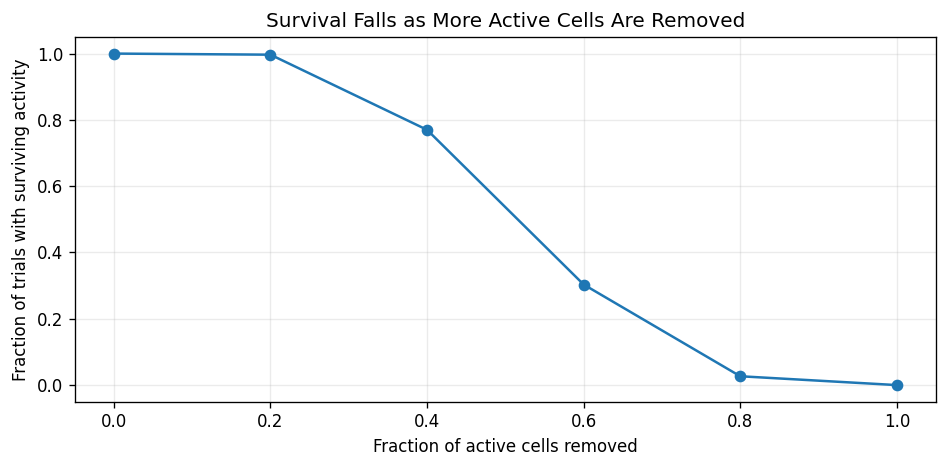

[1.0, 0.9966666666666667, 0.77, 0.30333333333333334, 0.02666666666666667, 0.0]

In [6]:
rng = np.random.default_rng(EXPERIMENT["seed"]); base = empty_world(EXPERIMENT["world"])
for r,c in [(18,18),(18,25),(25,18),(25,25)]: place(base, GLIDER, r, c)
rates=[]
for level in EXPERIMENT["damage_levels"]:
    survived=0
    for _ in range(EXPERIMENT["trials"]):
        h = run_life(random_damage(base, level, rng), EXPERIMENT["evaluation_steps"])
        survived += survives(h[-1])
    rates.append(survived / EXPERIMENT["trials"])
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(EXPERIMENT["damage_levels"], rates, marker="o"); ax.set(ylim=(-.05,1.05), title="Survival Falls as More Active Cells Are Removed", xlabel="Fraction of active cells removed", ylabel="Fraction of trials with surviving activity"); ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(FIG_DIR / "ch05-damage-survival-curve.png", bbox_inches="tight"); plt.show()
rates


## What the evidence supports

The glider persists undisturbed, but selected one-cell damage can destroy its characteristic trajectory. The curve is a robustness-style survival measurement, not evidence of regeneration.

## Provenance

**Book chapter**

`content/books/digital-life/05-kill-it/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch05_kill_it.py`

**Book figures reproduced**

- `static/images/books/digital-life/ch05-damage-survival-curve.png`
